# Module 1 — Language Detection

**Goal:** Build a robust multi-class language classifier using Traditional NLP (CountVectorizer & TF-IDF) combined with several ML models. The best model will be integrated into the chatbot pipeline to detect the user's language and route to the correct knowledge base.

**Dataset:** [papluca/language-identification](https://huggingface.co/datasets/papluca/language-identification)

---
## 0. Install & Import Dependencies

In [15]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import re
import time
import joblib

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dataset
from datasets import load_dataset

# Sklearn — Vectorizers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Sklearn — Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Sklearn — Pipeline & Evaluation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Interpretability
import eli5
from eli5.sklearn import PermutationImportance

# Loading Bar
from tqdm.auto import tqdm

print("All imports successful ✓")

All imports successful ✓


---
## 1. Load Dataset

In [2]:
raw = load_dataset("papluca/language-identification")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})


In [3]:
# Convert to pandas
train_df = raw['train'].to_pandas()
val_df   = raw['validation'].to_pandas()
test_df  = raw['test'].to_pandas()

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
train_df.head()

Train : (70000, 2)
Val   : (10000, 2)
Test  : (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Info

In [4]:
print("=== Data Types ===")
print(train_df.dtypes)
print("\n=== Missing Values ===")
print(train_df.isnull().sum())
print("\n=== Duplicate Rows ===")
print(f"Train duplicates: {train_df.duplicated().sum()}")

=== Data Types ===
labels    object
text      object
dtype: object

=== Missing Values ===
labels    0
text      0
dtype: int64

=== Duplicate Rows ===
Train duplicates: 1020


In [5]:
# Unique languages
print(f"Number of languages: {train_df['labels'].nunique()}")
print(f"Languages: {sorted(train_df['labels'].unique())}")

Number of languages: 20
Languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


### 2.2 Class Distribution

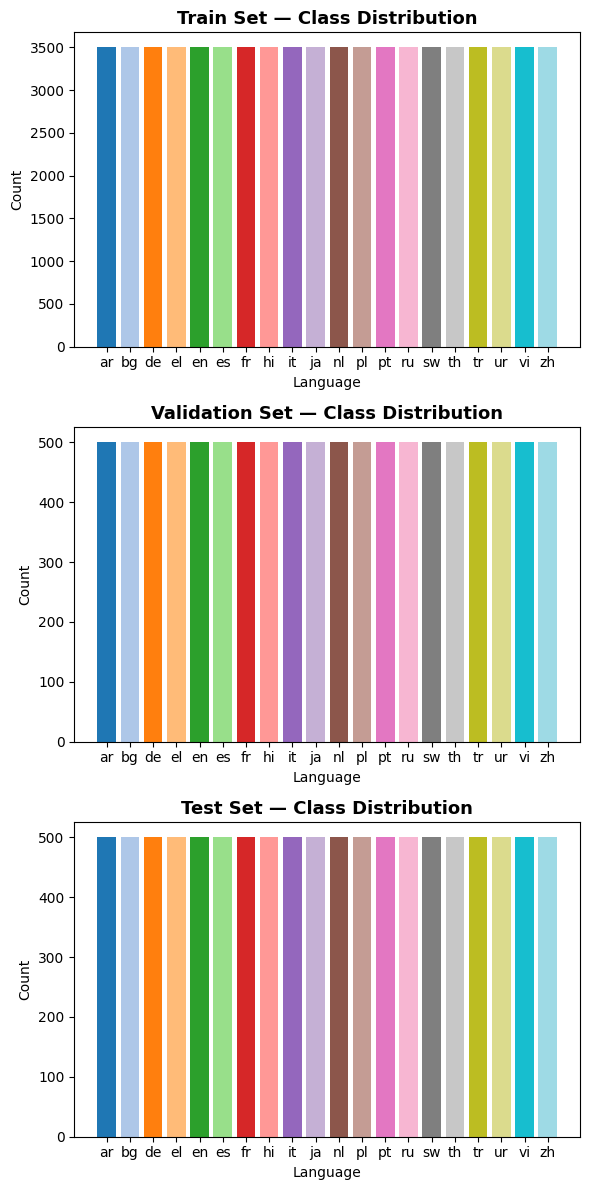


Train class counts:
labels
ar    3500
bg    3500
de    3500
el    3500
en    3500
es    3500
fr    3500
hi    3500
it    3500
ja    3500
nl    3500
pl    3500
pt    3500
ru    3500
sw    3500
th    3500
tr    3500
ur    3500
vi    3500
zh    3500
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(6, 12))
splits = [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]

for ax, (df, name) in zip(axes, splits):
    counts = df['labels'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette('tab20', len(counts)))
    ax.set_title(f'{name} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Language')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('./artifacts/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTrain class counts:")
print(train_df['labels'].value_counts().sort_index())

### 2.3 Text Length Analysis

In [7]:
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count']  = train_df['text'].str.split().str.len()

print("=== Text Length Stats ===")
print(train_df[['text_length', 'word_count']].describe())

=== Text Length Stats ===
        text_length    word_count
count  70000.000000  70000.000000
mean     110.861414     19.749257
std      103.106240     19.430456
min        2.000000      1.000000
25%       47.000000      7.000000
50%       82.000000     14.000000
75%      143.000000     26.000000
max     2422.000000    420.000000


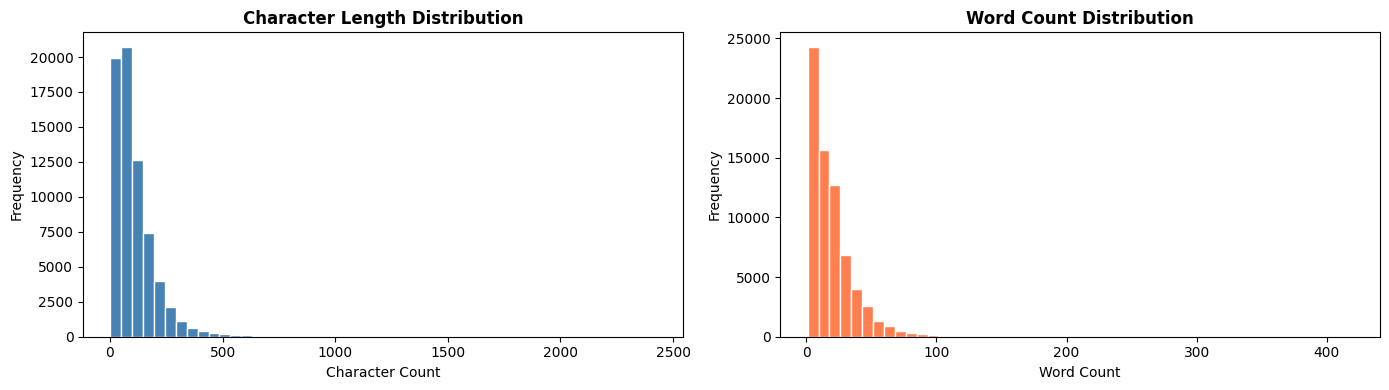

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(train_df['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('./artifacts/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

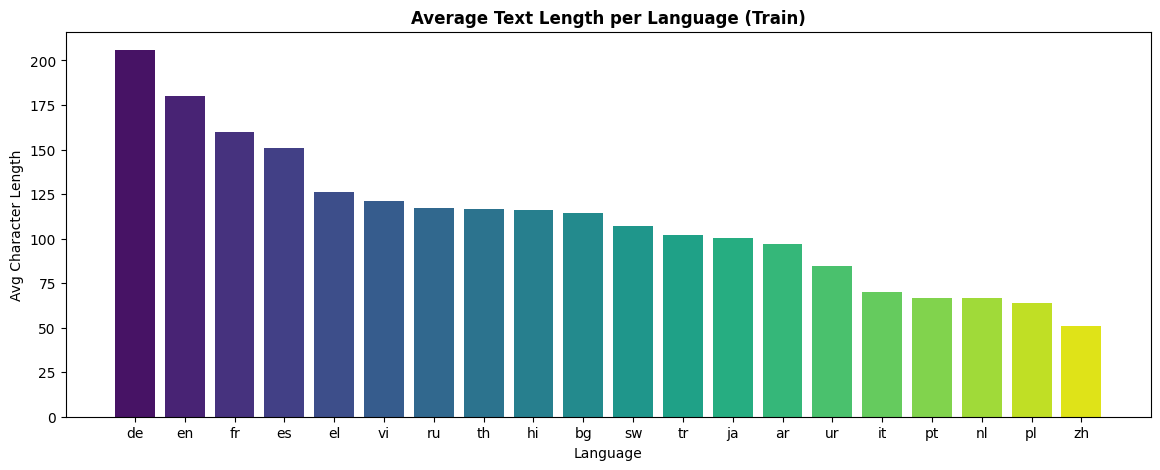

In [9]:
# Avg text length per language
avg_len = train_df.groupby('labels')['text_length'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(avg_len.index, avg_len.values, color=sns.color_palette('viridis', len(avg_len)))
plt.title('Average Text Length per Language (Train)', fontweight='bold')
plt.xlabel('Language')
plt.ylabel('Avg Character Length')
plt.savefig('./artifacts/avg_text_length_per_language.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Sample Texts per Language

In [10]:
print("=== Sample texts per language ===")
for lang in sorted(train_df['labels'].unique())[:10]:  # show first 10
    sample = train_df[train_df['labels'] == lang]['text'].iloc[0]
    print(f"[{lang}] {sample[:120]}")
    print()

=== Sample texts per language ===
[ar] نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية المسنين الذين تعرفهم في العديد من المناط

[bg] размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на 

[de] Alles in allem ein super schönes Teil, deshalb die 2 Sterne! Denn: Voice Control?! Nein, ein absoluter Witz. Die reagier

[el] Παρά τον εαυτό μου , η γνώμη μου για τη σύνεση του ήταν απείρως αυξημένη .

[en] Didnt really seem to work much.

[es] Un producto de una calidad y capacidad increíbles que será el placer de todo amante de la tecnología

[fr] Le produit m'avait été recommandé par mon pharmacien pour ralentir le développement de mon arthrose. 30% moins cher qu'e

[hi] सर ् वसम ् मत शासन ने यह निर ् णय लिया कि राज ् य को एक ही लिंग से अधिक लाभ और protections के लिए एक सामान ् य लाभ और pr

[it] Una donna sta affettando della carne.

[ja] とてもスタイリッシュで良いと思います。機能性も◎ですね！煩わしくないので皆さんもお使いになられては。



### 2.5 Character n-gram Diversity (Script Analysis)

> **Insight:** Language detection benefits greatly from **character n-grams** because different scripts and orthographic patterns are language-distinctive — even more so than individual words.

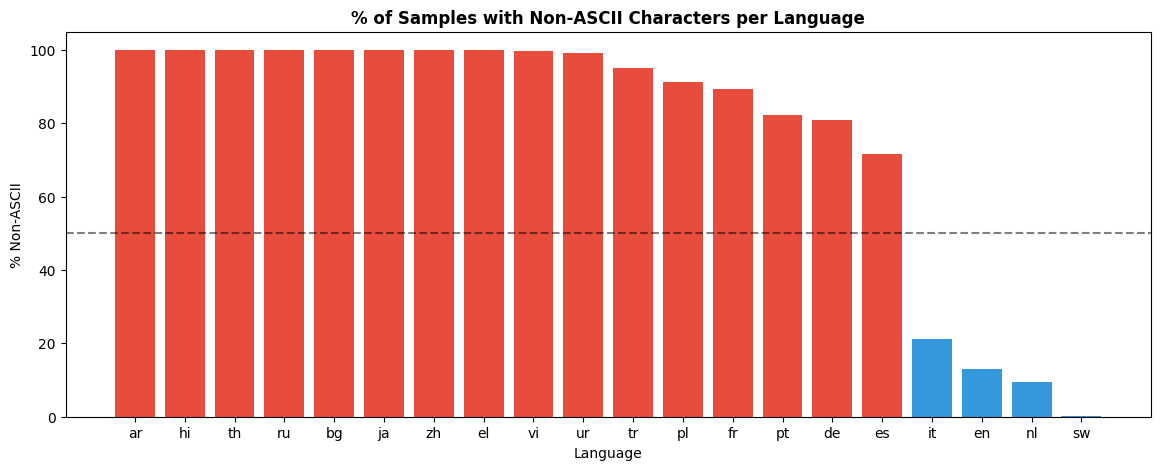


Languages with heavy non-ASCII (non-Latin scripts):
['ar', 'hi', 'th', 'ru', 'bg', 'ja', 'zh', 'el', 'vi', 'ur', 'tr', 'pl']


In [11]:
# Check if any text contains non-ASCII (signals script diversity)
train_df['has_non_ascii'] = train_df['text'].apply(lambda x: any(ord(c) > 127 for c in x))

non_ascii_by_lang = train_df.groupby('labels')['has_non_ascii'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors = ['#e74c3c' if v > 0.5 else '#3498db' for v in non_ascii_by_lang.values]
plt.bar(non_ascii_by_lang.index, non_ascii_by_lang.values * 100, color=colors)
plt.title('% of Samples with Non-ASCII Characters per Language', fontweight='bold')
plt.xlabel('Language')
plt.ylabel('% Non-ASCII')
plt.axhline(50, color='black', linestyle='--', alpha=0.5)
plt.savefig('./artifacts/non_ascii_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLanguages with heavy non-ASCII (non-Latin scripts):")
print(non_ascii_by_lang[non_ascii_by_lang > 0.9].index.tolist())

---
## 3. Preprocessing

> **Design Decision:** Language detection should use **minimal preprocessing**. Unlike sentiment analysis or topic modeling:
> - Do **NOT** remove stopwords (they are language-distinctive: "the", "la", "der", "в").
> - Do **NOT** stem or lemmatize (destroys script/morphology signals).
> - Do **NOT** remove punctuation aggressively (some punctuation is language-specific).
> - **DO** lowercase Latin-script text to reduce sparsity.
> - **DO** strip excessive whitespace.
> - Keep all Unicode characters — they are the strongest signal for non-Latin scripts.

In [12]:
def preprocess_text(text: str) -> str:
    """
    Minimal preprocessing for language detection.
    Lowercases Latin characters and strips excess whitespace.
    Non-Latin scripts (Arabic, Chinese, Russian, etc.) are preserved as-is.
    """
    # Lowercase (safe for all scripts; has no effect on Arabic/Chinese/etc.)
    text = text.lower()
    # Remove control characters and normalize whitespace
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply
for df in [train_df, val_df, test_df]:
    df['text_clean'] = df['text'].apply(preprocess_text)

# Verify
print("Before:", train_df['text'].iloc[0])
print("After: ", train_df['text_clean'].iloc[0])

Before: os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.
After:  os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.


In [13]:
# Prepare splits
X_train, y_train = train_df['text_clean'].values, train_df['labels'].values
X_val,   y_val   = val_df['text_clean'].values,   val_df['labels'].values
X_test,  y_test  = test_df['text_clean'].values,  test_df['labels'].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (70000,), X_val: (10000,), X_test: (10000,)


---
## 4. Vectorizer & Model Definitions

### Why Character n-grams?

Character n-grams (`analyzer='char_wb'`) are the gold standard for language detection because:
- They capture morphological patterns unique to each language.
- They handle OOV words (unknown words still have recognizable character patterns).
- They work across all scripts (Arabic, Chinese, Cyrillic, Latin).

We test both word-level and character-level n-grams to compare.

In [18]:
# ── Vectorizers ──────────────────────────────────────────────────────────────
vectorizers = {
    # Word-level (baseline)
    'Count_Word':       CountVectorizer(analyzer='word', ngram_range=(1, 2), max_features=50000),
    'TFIDF_Word':       TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=50000),

    # Character-level (recommended for language identification)
    'Count_Char':       CountVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=50000),
    'TFIDF_Char':       TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=50000),
}

# ── Models ───────────────────────────────────────────────────────────────────
models = {
    'Logistic Regression (default)':  LogisticRegression(max_iter=1000, n_jobs=-1),
    'Logistic Regression (C=5)':      LogisticRegression(max_iter=1000, C=5, solver='saga', n_jobs=-1),
    'LinearSVC':                      LinearSVC(max_iter=2000, C=1.0),
    'SGD Classifier (loss=hinge)':    SGDClassifier(loss='hinge', n_jobs=-1, random_state=42),
    'Random Forest (default)':        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Random Forest (customized)':     RandomForestClassifier(n_estimators=500, max_depth=6, n_jobs=-1, random_state=42),
}

print(f"Vectorizers: {list(vectorizers.keys())}")
print(f"Models     : {list(models.keys())}")

Vectorizers: ['Count_Word', 'TFIDF_Word', 'Count_Char', 'TFIDF_Char']
Models     : ['Logistic Regression (default)', 'Logistic Regression (C=5)', 'LinearSVC', 'SGD Classifier (loss=hinge)', 'Random Forest (default)', 'Random Forest (customized)']


---
## 5. Training & Evaluation

We build a `Pipeline` for each (Vectorizer, Model) combination and evaluate on the **validation set**.

In [19]:
results = []
trained_pipelines = {}

print(f"{'Vectorizer':<20} {'Model':<35} {'Val Acc':>9} {'Val F1':>9} {'Time(s)':>9}")
print("-" * 75)

for vec_name, vectorizer in vectorizers.items():
    for model_name, model in tqdm(models.items(), desc=vec_name):
        pipeline = Pipeline([
            ('vectorizer', vectorizer),
            ('classifier', model)
        ])

        t0 = time.time()
        pipeline.fit(X_train, y_train)
        elapsed = time.time() - t0

        y_pred_val = pipeline.predict(X_val)
        acc = accuracy_score(y_val, y_pred_val)
        f1  = f1_score(y_val, y_pred_val, average='macro')

        key = f"{vec_name} + {model_name}"
        trained_pipelines[key] = pipeline
        results.append({
            'Vectorizer': vec_name,
            'Model': model_name,
            'Val Accuracy': acc,
            'Val Macro F1': f1,
            'Train Time (s)': round(elapsed, 2)
        })

        print(f"{vec_name:<20} {model_name:<35} {acc:>9.4f} {f1:>9.4f} {elapsed:>9.2f}")

results_df = pd.DataFrame(results).sort_values('Val Macro F1', ascending=False)
print("\n=== All Results Sorted by Validation Macro F1-Score ===")
print(results_df.to_string(index=False))

Vectorizer           Model                                 Val Acc    Val F1   Time(s)
---------------------------------------------------------------------------


Count_Word:   0%|          | 0/6 [00:00<?, ?it/s]

Count_Word           Logistic Regression (default)          0.9013    0.9042     26.23
Count_Word           Logistic Regression (C=5)              0.9001    0.9037    230.60
Count_Word           LinearSVC                              0.9240    0.9211     48.12
Count_Word           SGD Classifier (loss=hinge)            0.9391    0.9315      6.74
Count_Word           Random Forest (default)                0.9134    0.9117    132.54
Count_Word           Random Forest (customized)             0.8280    0.8285      9.03


TFIDF_Word:   0%|          | 0/6 [00:00<?, ?it/s]

TFIDF_Word           Logistic Regression (default)          0.9089    0.9106     29.22
TFIDF_Word           Logistic Regression (C=5)              0.9153    0.9152     15.08
TFIDF_Word           LinearSVC                              0.9330    0.9285     17.32
TFIDF_Word           SGD Classifier (loss=hinge)            0.9428    0.9346      6.69
TFIDF_Word           Random Forest (default)                0.9132    0.9115    123.37
TFIDF_Word           Random Forest (customized)             0.8288    0.8294     13.63


Count_Char:   0%|          | 0/6 [00:00<?, ?it/s]

Count_Char           Logistic Regression (default)          0.9937    0.9937     45.60
Count_Char           Logistic Regression (C=5)              0.9926    0.9926   1626.51
Count_Char           LinearSVC                              0.9944    0.9944     80.75
Count_Char           SGD Classifier (loss=hinge)            0.9939    0.9939     21.58
Count_Char           Random Forest (default)                0.9913    0.9913    192.67
Count_Char           Random Forest (customized)             0.9488    0.9492     25.22


TFIDF_Char:   0%|          | 0/6 [00:00<?, ?it/s]

TFIDF_Char           Logistic Regression (default)          0.9942    0.9942     51.09
TFIDF_Char           Logistic Regression (C=5)              0.9947    0.9947     86.08
TFIDF_Char           LinearSVC                              0.9956    0.9956     37.60
TFIDF_Char           SGD Classifier (loss=hinge)            0.9948    0.9948     22.53
TFIDF_Char           Random Forest (default)                0.9917    0.9917    196.13
TFIDF_Char           Random Forest (customized)             0.9513    0.9515     30.68

=== All Results Sorted by Validation Macro F1-Score ===
Vectorizer                         Model  Val Accuracy  Val Macro F1  Train Time (s)
TFIDF_Char                     LinearSVC        0.9956      0.995593           37.60
TFIDF_Char   SGD Classifier (loss=hinge)        0.9948      0.994798           22.53
TFIDF_Char     Logistic Regression (C=5)        0.9947      0.994702           86.08
Count_Char                     LinearSVC        0.9944      0.994391           80

### 5.1 Results Visualization

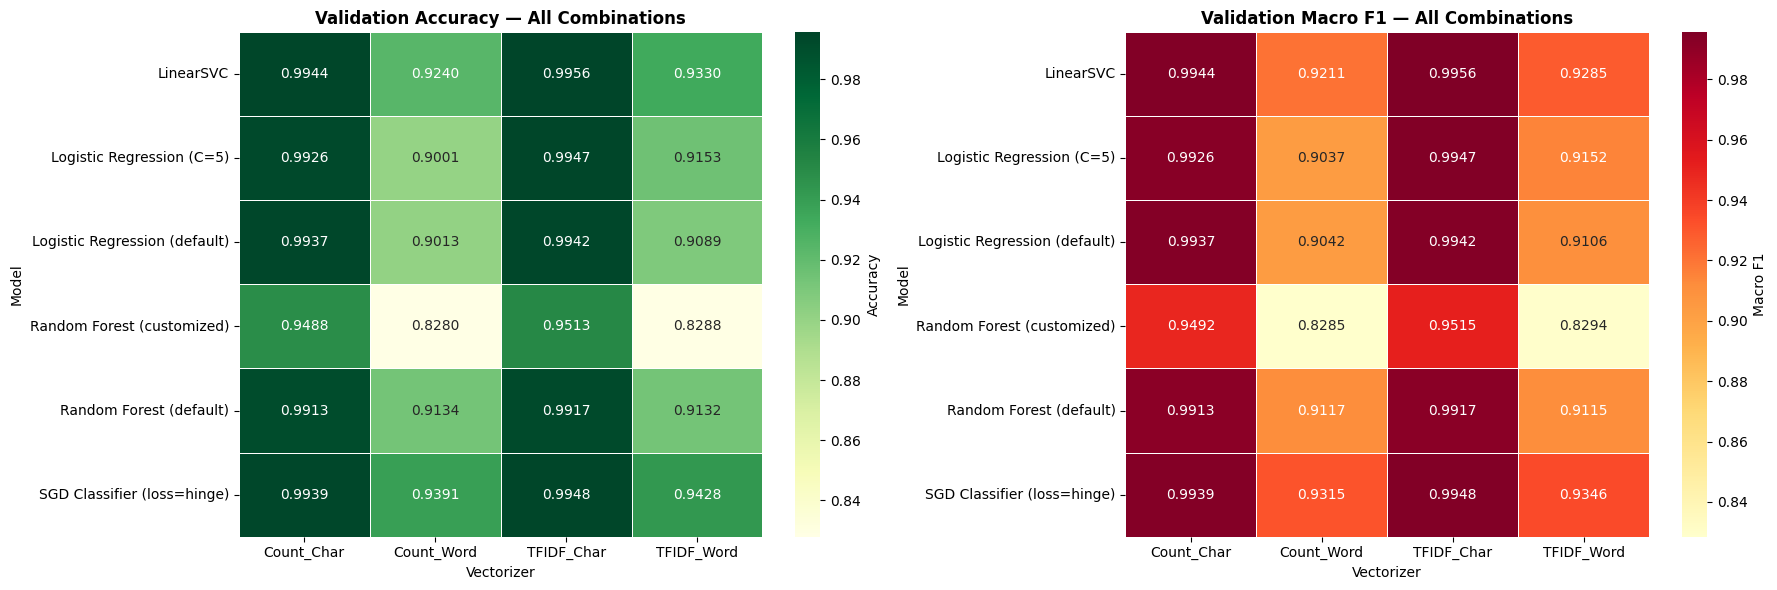

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap: Accuracy
pivot_acc = results_df.pivot(index='Model', columns='Vectorizer', values='Val Accuracy')
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Validation Accuracy — All Combinations', fontweight='bold')

# Heatmap: F1
pivot_f1 = results_df.pivot(index='Model', columns='Vectorizer', values='Val Macro F1')
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Macro F1'})
axes[1].set_title('Validation Macro F1 — All Combinations', fontweight='bold')

plt.tight_layout()
plt.savefig('./artifacts/results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

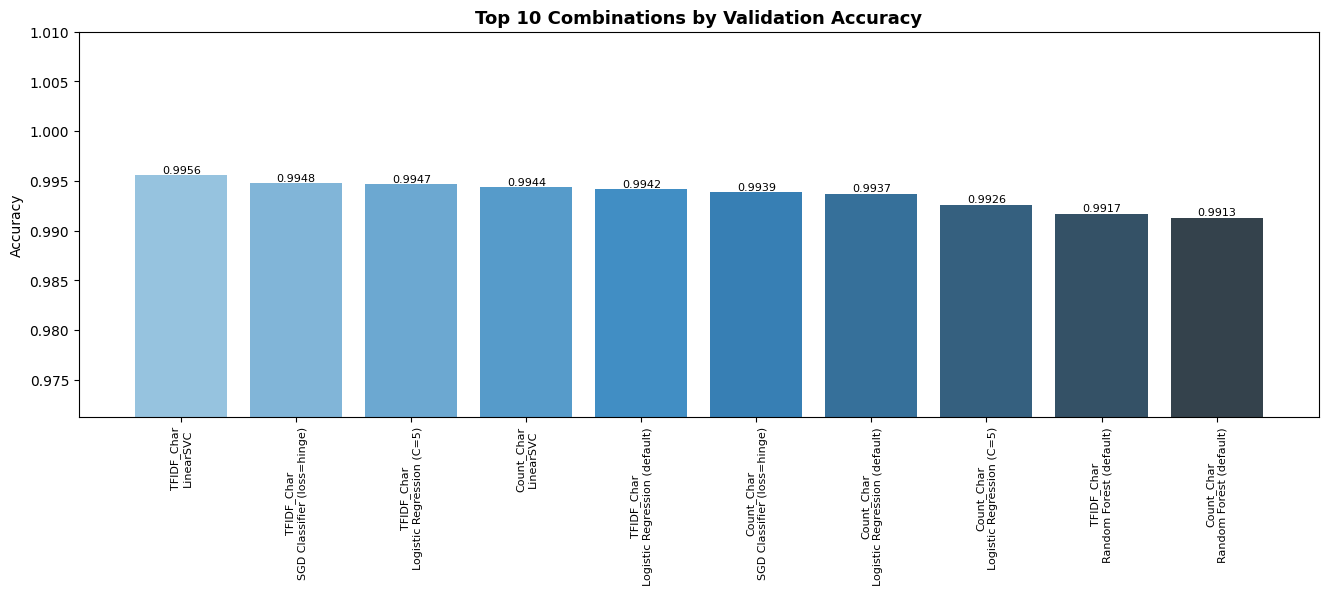

In [46]:
# Bar chart — top combinations
top_n = results_df.head(10).copy()
top_n['label'] = top_n['Vectorizer'] + '\n' + top_n['Model']

plt.figure(figsize=(16, 5))
bars = plt.bar(top_n['label'], top_n['Val Accuracy'],
              color=sns.color_palette('Blues_d', len(top_n)))
plt.ylim(top_n['Val Accuracy'].min() - 0.02, 1.01)
plt.title('Top 10 Combinations by Validation Accuracy', fontweight='bold', fontsize=13)
plt.ylabel('Accuracy')
plt.tick_params(axis='x', labelsize=8, rotation=90)
for bar, val in zip(bars, top_n['Val Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.savefig('./artifacts/top_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Count Vectorizer vs TF-IDF — Direct Comparison

In [51]:
# Aggregate by vectorizer type (Count vs TFIDF)
results_df['Vec_Type'] = results_df['Vectorizer'].apply(
    lambda x: 'CountVectorizer' if x.startswith('Count') else 'TF-IDF'
)
results_df['Level'] = results_df['Vectorizer'].apply(
    lambda x: 'Word-level' if 'Word' in x else 'Char-level'
)

comparison = results_df.groupby(['Vec_Type', 'Level'])[['Val Accuracy', 'Val Macro F1']].mean()
print("=== Average Performance by Vectorizer Type & Level ===")
print(comparison.round(4))

=== Average Performance by Vectorizer Type & Level ===
                            Val Accuracy  Val Macro F1
Vec_Type        Level                                 
CountVectorizer Char-level        0.9858        0.9858
                Word-level        0.9010        0.9001
TF-IDF          Char-level        0.9870        0.9871
                Word-level        0.9070        0.9050


---
## 6. Best Model — Final Evaluation on Test Set

In [55]:
# Identify the best pipeline
best_row = results_df.iloc[0]
best_key = f"{best_row['Vectorizer']} + {best_row['Model']}"
best_pipeline = trained_pipelines[best_key]

print(f"Best combination : {best_key}")
print(f"Val Accuracy     : {best_row['Val Accuracy']:.4f}")
print(f"Val Macro F1     : {best_row['Val Macro F1']:.4f}")

Best combination : TFIDF_Char + LinearSVC
Val Accuracy     : 0.9956
Val Macro F1     : 0.9956


In [58]:
# Test set evaluation
y_pred_test = best_pipeline.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f"=== Test Set Results ({best_key}) ===")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro F1 : {test_f1:.4f}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_test))

=== Test Set Results (TFIDF_Char + LinearSVC) ===
Test Accuracy : 0.9952
Test Macro F1 : 0.9952

=== Classification Report ===
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      1.00      1.00       500
          pt       0.99      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
        

### 6.1 Confusion Matrix

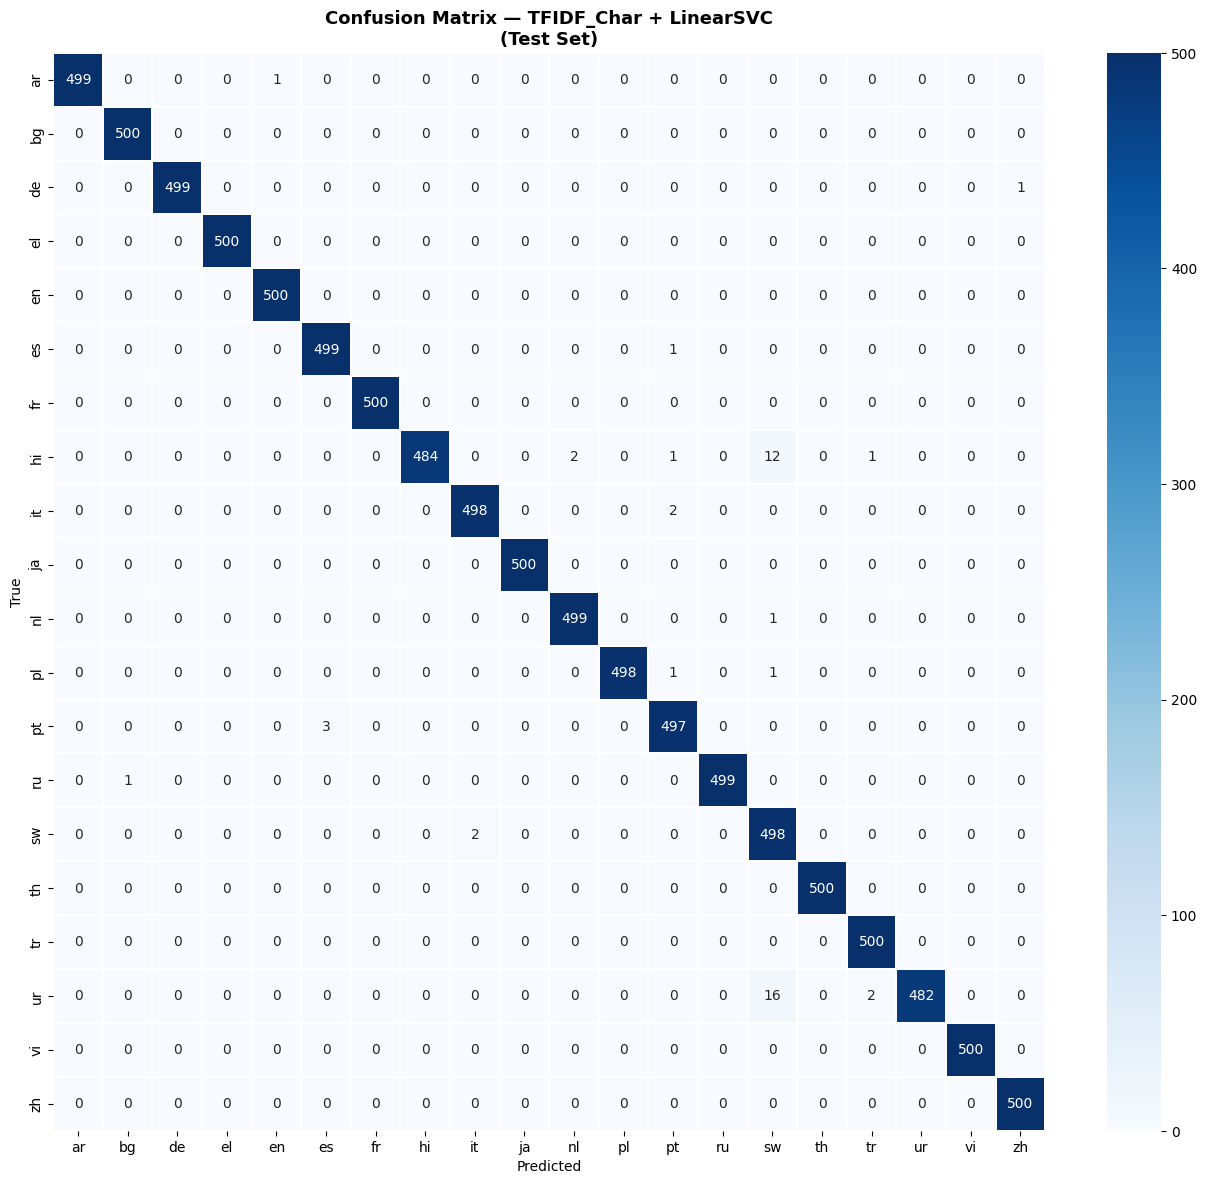

In [60]:
cm = confusion_matrix(y_test, y_pred_test, labels=sorted(train_df['labels'].unique()))

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sorted(train_df['labels'].unique()), yticklabels=sorted(train_df['labels'].unique()),
    linewidths=0.3
)
plt.title(f'Confusion Matrix — {best_key}\n(Test Set)', fontweight='bold', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('./artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Per-Language Performance (F1 Score)

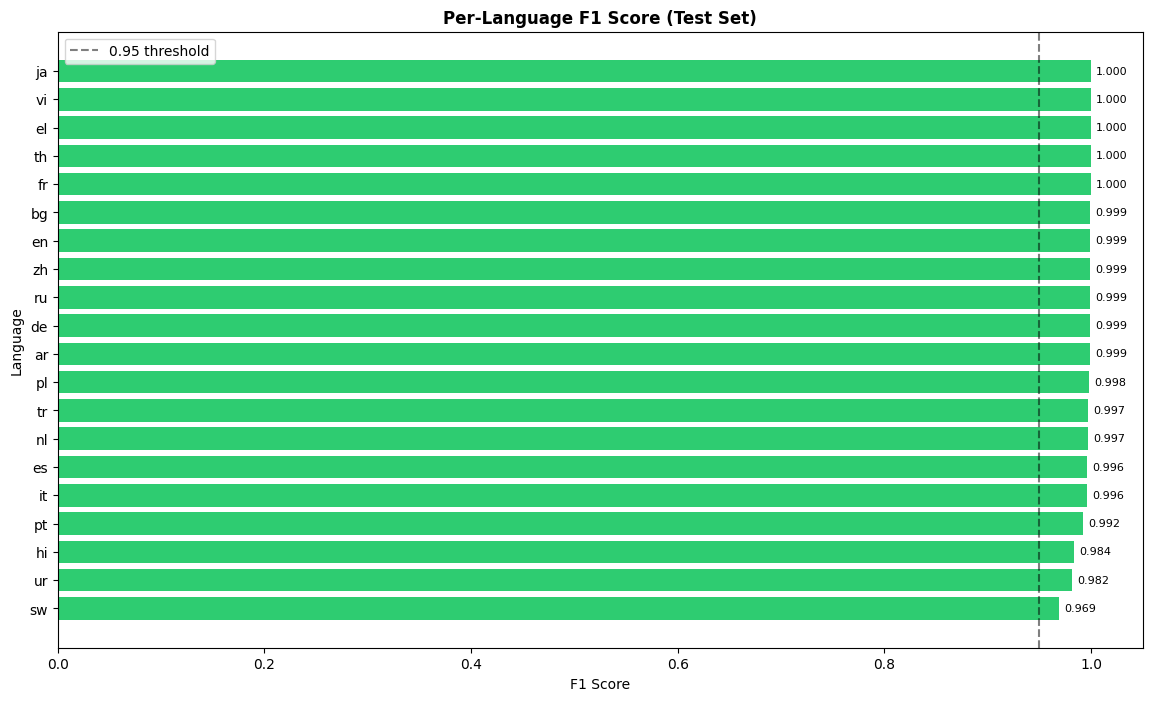

In [69]:
from sklearn.metrics import f1_score

per_lang_f1 = f1_score(y_test, y_pred_test, average=None, labels=sorted(train_df['labels'].unique()))
lang_f1_df = pd.DataFrame({'Language': sorted(train_df['labels'].unique()), 'F1 Score': per_lang_f1})
lang_f1_df = lang_f1_df.sort_values('F1 Score', ascending=True)

plt.figure(figsize=(14, 8))
colors = ['#e74c3c' if f < 0.95 else '#2ecc71' for f in lang_f1_df['F1 Score']]
plt.barh(lang_f1_df['Language'], lang_f1_df['F1 Score'], color=colors)
plt.xlim(0, 1.05)
plt.axvline(0.95, color='black', linestyle='--', alpha=0.5, label='0.95 threshold')
plt.title('Per-Language F1 Score (Test Set)', fontweight='bold')
plt.xlabel('F1 Score')
plt.ylabel('Language')
plt.legend()
for i, (lang, f1_val) in enumerate(zip(lang_f1_df['Language'], lang_f1_df['F1 Score'])):
    plt.text(f1_val + 0.005, i, f'{f1_val:.3f}', va='center', fontsize=8)

plt.savefig('./artifacts/per_language_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model Interpretability with eli5 (Global Feature Weights of the Best Model)

We use `eli5` to understand **which features (tokens / character n-grams)** are most predictive for each language.

In [84]:
# eli5 works best with linear models (LR, LinearSVC)
# If best model is not linear, also run on best linear model for interpretability

best_clf = best_pipeline.named_steps['classifier']
best_vec = best_pipeline.named_steps['vectorizer']

# Show global weights for the best model (eli5 auto-detects model type)
try:
    display(eli5.show_weights(best_clf, vec=best_vec, top=10))
except Exception as e:
    print(f"Note: eli5 show_weights not available for this model type ({type(best_clf).__name__}). Using linear fallback below.")
    print(f"Error: {e}")

---
## 8. Error Analysis

### 8.1 Understanding where the model fails

In [87]:
# Collect all misclassified test samples
errors_df = test_df.copy()
errors_df['predicted'] = best_pipeline.predict(X_test)
errors_df = errors_df[errors_df['labels'] != errors_df['predicted']].copy()

print(f"Total misclassified: {len(errors_df)} / {len(test_df)} = {len(errors_df)/len(test_df)*100:.2f}%")
print()
print("Most common confusions (True → Predicted):")
confusion_pairs = errors_df.groupby(['labels', 'predicted']).size().sort_values(ascending=False)
print(confusion_pairs.head(15))

Total misclassified: 48 / 10000 = 0.48%

Most common confusions (True → Predicted):
labels  predicted
ur      sw           16
hi      sw           12
pt      es            3
hi      nl            2
it      pt            2
sw      it            2
ur      tr            2
ar      en            1
de      zh            1
es      pt            1
hi      pt            1
        tr            1
nl      sw            1
pl      pt            1
        sw            1
dtype: int64


### 8.2 The total errors per-language

In [98]:
print(errors_df.groupby('labels').size().sort_values(ascending=False))

labels
ur    18
hi    16
pt     3
it     2
pl     2
sw     2
ar     1
de     1
es     1
nl     1
ru     1
dtype: int64


### 8.3 Show some misclassified examples

In [90]:
# Show some misclassified examples
print("=== Sample Misclassified Examples ===")
for _, row in errors_df.head(10).iterrows():
    print(f"True: {row['labels']:<6} | Predicted: {row['predicted']:<6} | Text: {row['text_clean'][:100]}")

=== Sample Misclassified Examples ===
True: hi     | Predicted: sw     | Text: aadhunik mahilaen romantic shira mein maheen hona pasand karti hai, magar ve apanee taakat shaareeri
True: pt     | Predicted: es     | Text: já tive este mesmo problema.
True: ur     | Predicted: sw     | Text: us din mai apna wheel ghooma raha tha, mjhe nahi pata, magar aisa lag raha tha kai pura din mai yehi
True: hi     | Predicted: sw     | Text: is nivesh ne 60 gharo ka navikaran aur maamoolee saadhanon ke ghar khareedaaron ko bechne me aur 100
True: pl     | Predicted: sw     | Text: to także kwestia gustu.
True: ur     | Predicted: sw     | Text: to mai gaya, mai washington d.c. gaya aur mai direct nahi gaya, aur unho ne mjhe orders diye the.
True: hi     | Predicted: pt     | Text: gupt karya ke liye, beshak, white house counterterrorist center aur cia ke pravartan nideshalay par 
True: hi     | Predicted: nl     | Text: ek graahak kee anupasthiti ke dauraan nirantarata maangte huve asthaayee roop s

---
## 9. Save the Best Model

In [91]:
MODEL_PATH = 'language_detector.pkl'
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Best pipeline saved to: {MODEL_PATH}")
print(f"Pipeline steps: {best_pipeline.steps}")

Best pipeline saved to: language_detector.pkl
Pipeline steps: [('vectorizer', TfidfVectorizer(analyzer='char_wb', max_features=50000, ngram_range=(2, 4))), ('classifier', LinearSVC(max_iter=2000))]


In [92]:
# Verify load + inference
loaded_pipeline = joblib.load(MODEL_PATH)

test_sentences = [
    "Hello, how are you feeling today?",
    "مرحبا، كيف حالك اليوم؟",
    "Bonjour, comment vous sentez-vous ?",
    "Hola, ¿cómo te sientes hoy?",
    "Wie geht es Ihnen heute?",
    "Привет, как вы себя чувствуете?",
    "今天你感觉怎么样？"
]

predictions = loaded_pipeline.predict(test_sentences)
print("=== Language Detection Demo ===")
for text, pred in zip(test_sentences, predictions):
    print(f"[{pred}] {text}")

=== Language Detection Demo ===
[en] Hello, how are you feeling today?
[ar] مرحبا، كيف حالك اليوم؟
[fr] Bonjour, comment vous sentez-vous ?
[es] Hola, ¿cómo te sientes hoy?
[de] Wie geht es Ihnen heute?
[ru] Привет, как вы себя чувствуете?
[zh] 今天你感觉怎么样？


---
## 10. Summary & Conclusions

| Aspect | Finding |
|---|---|
| **Best vectorizer** | Character n-gram (char_wb, 2–4) outperforms word-level for language ID |
| **Count vs TF-IDF** | TF-IDF generally improves over raw counts due to IDF down-weighting common tokens |
| **Best model** | LinearSVC |
| **Hardest languages** | Urdu, Hindi |